Full dataset shape: (725, 12)
   id  period  treatment  x1        x2  x3        x4  age     age_s  outcome  \
0   1       0          1   1  1.146148   0  0.734203   36  0.083333        0   
1   1       1          1   1  0.002200   0  0.734203   37  0.166667        0   
2   1       2          1   0 -0.481762   0  0.734203   38  0.250000        0   
3   1       3          1   0  0.007872   0  0.734203   39  0.333333        0   
4   1       4          1   1  0.216054   0  0.734203   40  0.416667        0   

   censored  eligible  
0         0         1  
1         0         0  
2         0         0  
3         0         0  
4         0         0  

Baseline dataset shape: (89, 12)
   id  period  treatment  x1        x2  x3        x4  age     age_s  outcome  \
0   1       0          1   1  1.146148   0  0.734203   36  0.083333        0   
1   2       0          0   1 -0.802142   0 -0.990794   26 -0.750000        0   
2   3       0          1   0  0.571029   1  0.391966   48  1.083333    

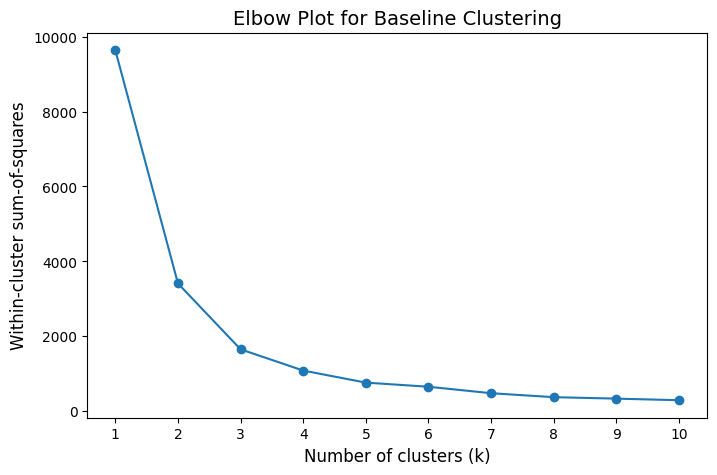


Cluster Summary (Baseline covariates):
           x1    x2    x3    x4    age  age_s
cluster                                      
0        0.33 -0.19  0.58  0.50  26.18  -0.73
1        0.45  0.09  0.45 -0.26  40.02   0.42
2        0.44  0.00  0.56 -0.18  52.19   1.43


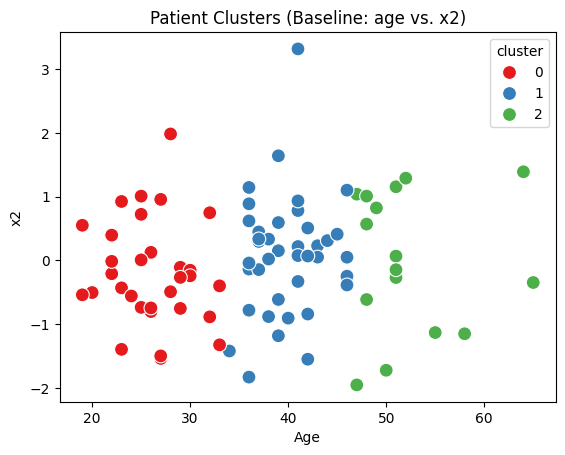


Merged dataset with cluster labels:
   id  period  treatment  x1        x2  x3        x4  age     age_s  outcome  \
0   1       0          1   1  1.146148   0  0.734203   36  0.083333        0   
1   1       1          1   1  0.002200   0  0.734203   37  0.166667        0   
2   1       2          1   0 -0.481762   0  0.734203   38  0.250000        0   
3   1       3          1   0  0.007872   0  0.734203   39  0.333333        0   
4   1       4          1   1  0.216054   0  0.734203   40  0.416667        0   
5   1       5          1   0 -0.057482   0  0.734203   41  0.500000        0   
6   2       0          0   1 -0.802142   0 -0.990794   26 -0.750000        0   
7   2       1          1   1 -0.983030   0 -0.990794   27 -0.666667        0   
8   2       2          1   0  0.399388   0 -0.990794   28 -0.583333        0   
9   2       3          0   0  1.835085   0 -0.990794   29 -0.500000        0   

   censored  eligible  cluster  
0         0         1        1  
1         0     

C:\Users\Alex\AppData\Local\Temp\ipykernel_12564\3791988254.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='cluster', y='outcome', palette='Set1')


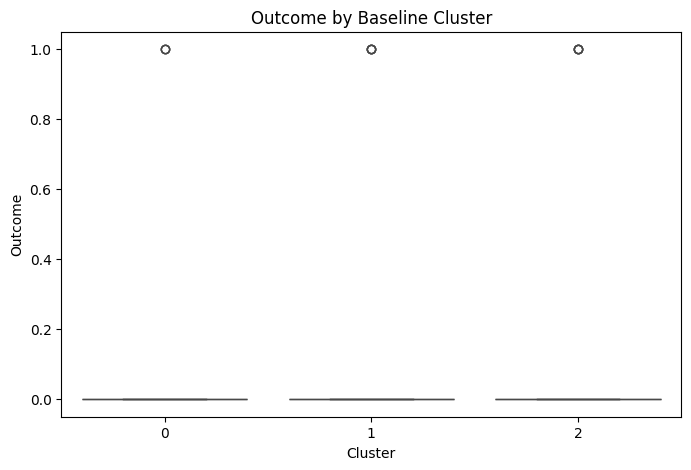


Average treatment (proportion) by cluster:
cluster
0    0.70
1    0.41
2    0.39
Name: treatment, dtype: float64


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# -----------------------------
# Step 1: Read in the dataset
# -----------------------------
# Adjust the filename/path as needed.
df_full = pd.read_csv("data_censored.csv")
print("Full dataset shape:", df_full.shape)
print(df_full.head())

# -------------------------------------------
# Step 2: Select baseline rows for each patient
# -------------------------------------------
# We assume that baseline is defined as the first (smallest period)
# for each id where eligible==1.
df_baseline = (df_full[df_full['eligible'] == 1]
               .sort_values(by=['id', 'period'])
               .groupby('id', as_index=False)
               .first())
print("\nBaseline dataset shape:", df_baseline.shape)
print(df_baseline.head())

# ------------------------------------------------
# Step 3: Select baseline covariates for clustering
# ------------------------------------------------
# Here we choose the variables x1, x2, x3, x4, age, and age_s.
# (You can adjust this list if needed.)
covariates = ['x1', 'x2', 'x3', 'x4', 'age', 'age_s']
X = df_baseline[covariates].copy()

# (Optional) You might want to standardize or scale these covariates.
# For simplicity, we use them as given.

# ---------------------------------------------------
# Step 4: Choose number of clusters using the elbow method
# ---------------------------------------------------
wcss = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)
    
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o')
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Within-cluster sum-of-squares', fontsize=12)
plt.title('Elbow Plot for Baseline Clustering', fontsize=14)
plt.xticks(k_range)
plt.show()

# Based on the elbow plot, set the number of clusters; here we choose k=3.
k = 3
km_final = KMeans(n_clusters=k, random_state=42)
df_baseline['cluster'] = km_final.fit_predict(X)

# -----------------------------------------------
# Step 5: Inspect and summarize the clusters
# -----------------------------------------------
cluster_summary = df_baseline.groupby('cluster')[covariates].mean().round(2)
print("\nCluster Summary (Baseline covariates):")
print(cluster_summary)

# Plot clusters using a pairplot (if dimensions allow) or scatter plot of two chosen variables:
sns.scatterplot(data=df_baseline, x='age', y='x2', hue='cluster', palette='Set1', s=100)
plt.title("Patient Clusters (Baseline: age vs. x2)")
plt.xlabel("Age")
plt.ylabel("x2")
plt.show()

# ------------------------------------------------------------
# Step 6: Merge cluster labels back into the full dataset
# ------------------------------------------------------------
# Merge on 'id' so that each row for a given patient inherits their baseline cluster.
df_merged = pd.merge(df_full, df_baseline[['id', 'cluster']], on='id', how='left')
print("\nMerged dataset with cluster labels:")
print(df_merged.head(10))

# ------------------------------------------------------------
# Step 7: Compare outcome (and treatment) by cluster
# ------------------------------------------------------------
# For example, we can plot the distribution of 'outcome' by cluster.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_merged, x='cluster', y='outcome', palette='Set1')
plt.title("Outcome by Baseline Cluster")
plt.xlabel("Cluster")
plt.ylabel("Outcome")
plt.show()

# You might also explore treatment assignment:
treatment_summary = df_merged.groupby('cluster')['treatment'].mean().round(2)
print("\nAverage treatment (proportion) by cluster:")
print(treatment_summary)


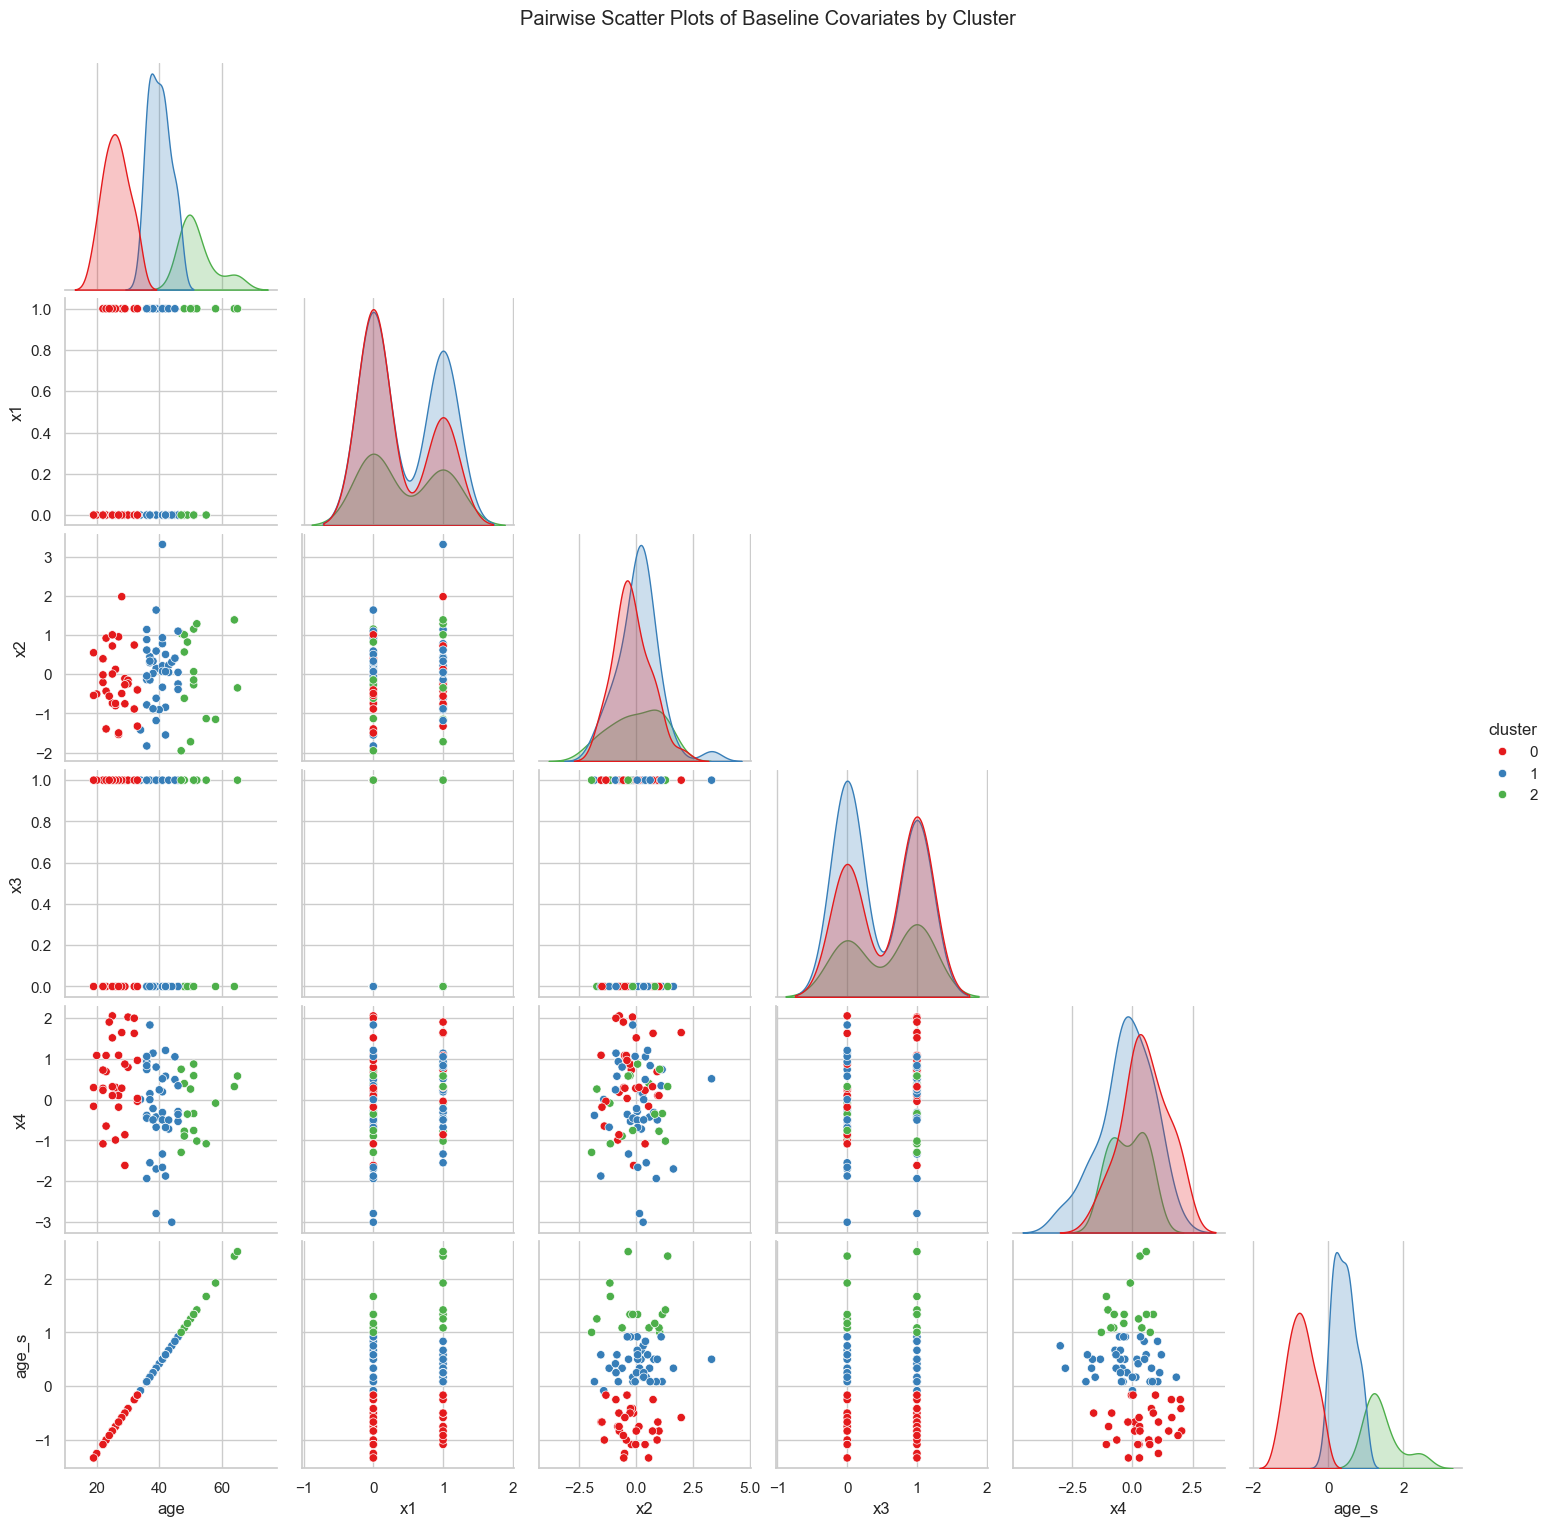

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Suppose df_baseline already has a 'cluster' column and the covariates:
#   x1, x2, x3, x4, age, age_s
# You can include or exclude any variables you'd like to visualize.

plot_vars = ['age','x1','x2','x3','x4','age_s']

sns.set(style="whitegrid")
g = sns.pairplot(
    df_baseline, 
    vars=plot_vars, 
    hue='cluster',   # color by cluster
    palette='Set1',  # choose a color palette
    diag_kind='kde', # show kernel density on diagonals
    corner=True      # show only the lower triangle if you want a simpler layout
)

# Optional: add a title
g.fig.suptitle("Pairwise Scatter Plots of Baseline Covariates by Cluster", y=1.02)

plt.show()
